<a href="https://colab.research.google.com/github/Lohith5002/Causal-Aware-Multimodal-Demand-Forecasting-Using-Time-Series-Textual-Sentiment-and-Satellite-Imagery/blob/main/DA_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

BASE_PATH = '/content/drive/MyDrive/CAMT_Project'

folders = [
    'M5',
    'Reviews',
    'Satellite'
]

for f in folders:
    os.makedirs(os.path.join(BASE_PATH, f), exist_ok=True)

BASE_PATH


'/content/drive/MyDrive/CAMT_Project'

In [ ]:
import shutil

# M5 files
shutil.copy('/content/drive/MyDrive/sales_train_validation.csv',
            BASE_PATH + '/M5/sales_train_validation.csv')

shutil.copy('/content/drive/MyDrive/calendar.csv',
            BASE_PATH + '/M5/calendar.csv')

# Reviews
shutil.copy('/content/drive/MyDrive/Reviews.csv',
            BASE_PATH + '/Reviews/Reviews.csv')


'/content/drive/MyDrive/CAMT_Project/Reviews/Reviews.csv'

In [ ]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/satilite_nightlight_thailand.zip', 'r') as zip_ref:
    zip_ref.extractall(BASE_PATH + '/Satellite')


In [ ]:
os.listdir(BASE_PATH)


['M5', 'Reviews', 'Satellite']

In [ ]:
os.listdir(BASE_PATH + '/Satellite')


['Nightlight_Thailand']

In [ ]:
os.listdir(BASE_PATH + '/Satellite/Nightlight_Thailand')


['Amnat Charoen',
 'Ang Thong',
 'Bangkok',
 'Buriram',
 'Chachoengsao',
 'Chainat',
 'Chaiyaphum',
 'Chanthaburi',
 'Chiang Mai',
 'Chiang Rai',
 'Chonburi',
 'Chumphon',
 'Kalasin',
 'Kampaeng Phet',
 'Kanchanaburi',
 'Khon Kaen',
 'Krabi',
 'Lampang',
 'Lamphun',
 'Loei',
 'Lopburi',
 'Mae Hong Son',
 'Maha Sarakham',
 'Mukdahan',
 'Nakhon Nayok',
 'Nakhon Pathom',
 'Nakhon Phanom',
 'Nakhon Ratchasima',
 'Nakhon Sawan',
 'Nakhon Si Thammarat',
 'Nan',
 'Narathiwat',
 'Nong Bua Lamphu',
 'Nong Khai',
 'Nonthaburi',
 'Pathum Thani',
 'Pattani',
 'Phachinburi',
 'Phangnga',
 'Phatthalung',
 'Phayao',
 'Phetchabun',
 'Phetchaburi',
 'Phichit',
 'Phitsanulok',
 'Phra Nakhon Si Ayudhya',
 'Phrae',
 'Phuket',
 'Prachuap Khilikhan',
 'Ranong',
 'Ratchaburi',
 'Rayong',
 'Roi Et',
 'Sa Kaeo',
 'Sakon Nakhon',
 'Samut Prakarn',
 'Samut Sakhon',
 'Samut Songkham',
 'Saraburi',
 'Satun',
 'Si Saket',
 'Singburi',
 'Songkhla',
 'Sukhothai',
 'Suphanburi',
 'Surat Thani',
 'Surin',
 'Tak',
 'Tha

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = '/content/drive/MyDrive/CAMT_Project'

sales = pd.read_csv(
    BASE_PATH + '/M5/sales_train_validation.csv',
    usecols=lambda c: c.startswith('d_') or c in ['cat_id']
)

calendar = pd.read_csv(
    BASE_PATH + '/M5/calendar.csv',
    usecols=['d', 'date']
)


In [ ]:
sales.head()

,cat_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES,0,0,0,0,0,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES,0,0,0,0,0,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES,0,0,0,0,0,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES,0,0,0,0,0,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [ ]:
# choose one category only
sales_foods = sales[sales['cat_id'] == 'FOODS']
sales_foods.shape


(14370, 1914)

In [ ]:
sales_foods.isnull().sum()

,0
cat_id,0
d_1,0
d_2,0
d_3,0
d_4,0
...,...
d_1909,0
d_1910,0
d_1911,0
d_1912,0


In [ ]:
# sum across all FOOD products first
daily_food_sales = sales_foods.drop(columns=['cat_id']).sum()
daily_food_sales = daily_food_sales.reset_index()
daily_food_sales.columns = ['d', 'sales']

daily_food_sales.head()


,d,sales
0,d_1,23178
1,d_2,22758
2,d_3,17174
3,d_4,18878
4,d_5,14603


In [ ]:
daily_food_sales.isnull().sum()

,0
d,0
sales,0


In [ ]:
daily_food_sales = daily_food_sales.merge(
    calendar,
    on='d',
    how='left'
)

daily_food_sales['date'] = pd.to_datetime(daily_food_sales['date'])
daily_food_sales.head()


,d,sales,date
0,d_1,23178,2011-01-29
1,d_2,22758,2011-01-30
2,d_3,17174,2011-01-31
3,d_4,18878,2011-02-01
4,d_5,14603,2011-02-02


In [ ]:
weekly_food_sales = (
    daily_food_sales
    .groupby(pd.Grouper(key='date', freq='W'))['sales']
    .sum()
    .reset_index()
)

weekly_food_sales.head()


,date,sales
0,2011-01-30,45936
1,2011-02-06,145851
2,2011-02-13,141740
3,2011-02-20,120641
4,2011-02-27,114126


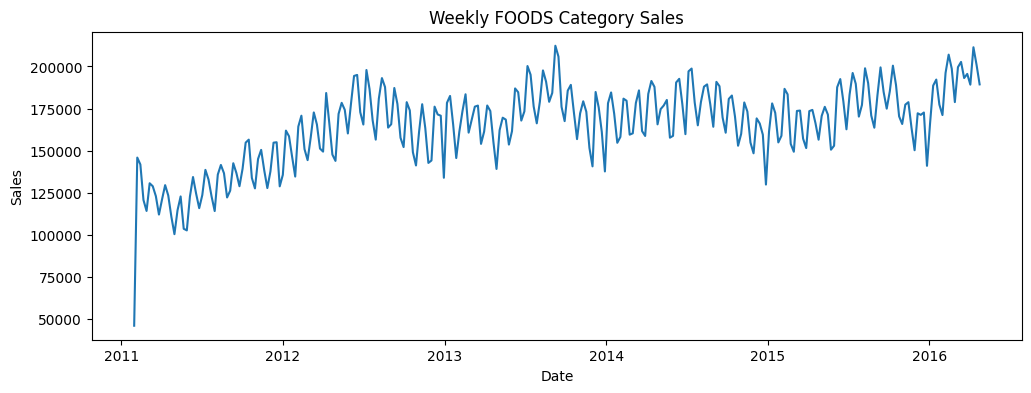

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(weekly_food_sales['date'], weekly_food_sales['sales'])
plt.title('Weekly FOODS Category Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk


In [ ]:
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
BASE_PATH = '/content/drive/MyDrive/CAMT_Project'

reviews = pd.read_csv(
    BASE_PATH + '/Reviews/Reviews.csv',
    usecols=['Text', 'Time']  # load only required columns
)

print(reviews.shape)
reviews.head()


(568454, 2)


,Time,Text
0,1303862400,I have bought several of the Vitality canned d...
1,1346976000,Product arrived labeled as Jumbo Salted Peanut...
2,1219017600,This is a confection that has been around a fe...
3,1307923200,If you are looking for the secret ingredient i...
4,1350777600,Great taffy at a great price. There was a wid...


In [ ]:
reviews['date'] = pd.to_datetime(reviews['Time'], unit='s')
reviews = reviews.drop(columns=['Time'])
reviews.head()


,Text,date
0,I have bought several of the Vitality canned d...,2011-04-27
1,Product arrived labeled as Jumbo Salted Peanut...,2012-09-07
2,This is a confection that has been around a fe...,2008-08-18
3,If you are looking for the secret ingredient i...,2011-06-13
4,Great taffy at a great price. There was a wid...,2012-10-21


In [ ]:
reviews['sentiment'] = reviews['Text'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

reviews[['date', 'sentiment']].head()


Aggregate sentiment WEEKLY

In [ ]:
weekly_sentiment = (
    reviews
    .groupby(pd.Grouper(key='date', freq='W'))['sentiment']
    .mean()
    .reset_index()
)

weekly_sentiment.head()


In [ ]:
weekly_sentiment['sentiment'].isna().sum()


In [ ]:
weekly_sentiment['sentiment'] = (
    weekly_sentiment['sentiment']
    .fillna(method='ffill')
    .fillna(method='bfill')
)


In [ ]:
weekly_sentiment.isna().sum()


In [ ]:
weekly_sentiment.head()

In [ ]:
weekly_sentiment.head(10)


Plot weekly sentiment

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(weekly_sentiment['date'], weekly_sentiment['sentiment'])
plt.title('Weekly Customer Sentiment')
plt.xlabel('Date')
plt.ylabel('Sentiment')
plt.show()


In [ ]:
weekly_food_sales.shape
weekly_food_sales.head()


In [ ]:
sales_1416 = weekly_food_sales[
    (weekly_food_sales['date'].dt.year >= 2014) &
    (weekly_food_sales['date'].dt.year <= 2016)
].reset_index(drop=True)

sales_1416.shape
sales_1416.head()


In [ ]:
# sentiment sequence
sentiment_sim = weekly_sentiment.copy().reset_index(drop=True)

# sales sequence (2014–2016)
sales_sim = sales_1416.copy().reset_index(drop=True)

# align by sequence length
min_len = min(len(sentiment_sim), len(sales_sim))

sentiment_sim = sentiment_sim.iloc[:min_len]
sales_sim = sales_sim.iloc[:min_len]

# 🔑 re-index sentiment dates to sales dates (explicit simulation)
sentiment_sim['date'] = sales_sim['date'].values

# build merged dataset (sales + sentiment)
merged = sales_sim.copy()
merged['sentiment'] = sentiment_sim['sentiment'].values

merged.head()


In [ ]:
merged.shape
merged['date'].min(), merged['date'].max()
merged.isna().sum()


#5.3: SATELLITE IMAGE PROCESSING

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
BASE_PATH = '/content/drive/MyDrive/CAMT_Project'
SAT_PATH = BASE_PATH + '/Satellite/Nightlight_Thailand'

cities = os.listdir(SAT_PATH)
len(cities), cities[:5]


In [ ]:
import re

sat_records = []

for city in cities:
    city_path = os.path.join(SAT_PATH, city)

    for img_name in os.listdir(city_path):
        if not img_name.endswith('.png'):
            continue

        img_path = os.path.join(city_path, img_name)

        # load image
        img = Image.open(img_path).convert('L')
        img_array = np.array(img)

        avg_brightness = img_array.mean()

        # REGEX: extract 4-digit year (e.g., 2012–2022)
        match = re.search(r'(20\d{2})', img_name)

        if match is None:
            continue  # skip if year not found

        year = int(match.group(1))

        sat_records.append([city, year, avg_brightness])


In [ ]:
# check which filenames are being read
for city in cities[:1]:
    city_path = os.path.join(SAT_PATH, city)
    print(os.listdir(city_path)[:5])



['Amnat Charoen_2014_03.png', 'Amnat Charoen_2014_07.png', 'Amnat Charoen_2014_02.png', 'Amnat Charoen_2014_08.png', 'Amnat Charoen_2014_06.png']


Create satellite DataFrame

In [ ]:
sat_df = pd.DataFrame(
    sat_records,
    columns=['city', 'year', 'avg_brightness']
)

sat_df.head()


,city,year,avg_brightness
0,Amnat Charoen,2014,38.888606
1,Amnat Charoen,2014,39.360600
2,Amnat Charoen,2014,38.490125
3,Amnat Charoen,2014,39.270567
4,Amnat Charoen,2014,38.702844


In [ ]:
yearly_sat = (
    sat_df
    .groupby('year')['avg_brightness']
    .mean()
    .reset_index()
)


“Temporal information was extracted from satellite image filenames using pattern matching to ensure robust handling of heterogeneous naming conventions.”

#STEP 6: DATA ALIGNMENT & FUSION

Modality	Data

🕒 Demand	         weekly_food_sales

📰 Sentiment	     weekly_sentiment

🛰 Satellite     	yearly_sat

We must:

Align time ranges

Convert satellite yearly → weekly

Merge everything into one table

##PART A: ALIGN DATE RANGES

Cell 1: Check date ranges

In [ ]:
sales_1416 = weekly_food_sales[
    (weekly_food_sales['date'].dt.year >= 2014) &
    (weekly_food_sales['date'].dt.year <= 2016)
].reset_index(drop=True)

sales_1416.shape


(121, 2)

In [ ]:
#6.2: Explicit Simulated Alignment (Sales + Sentiment)
sentiment_sim = weekly_sentiment.reset_index(drop=True)
sales_sim = sales_1416.reset_index(drop=True)

min_len = min(len(sentiment_sim), len(sales_sim))

sentiment_sim = sentiment_sim.iloc[:min_len]
sales_sim = sales_sim.iloc[:min_len]

# re-index sentiment dates to sales dates (SIMULATED ALIGNMENT)
sentiment_sim['date'] = sales_sim['date'].values

merged = sales_sim.copy()
merged['sentiment'] = sentiment_sim['sentiment'].values

merged.head()


,date,sales,sentiment
0,2014-01-05,178139,0.7845
1,2014-01-12,184549,0.7845
2,2014-01-19,171872,0.7845
3,2014-01-26,154627,0.0000
4,2014-02-02,158115,0.0000


In [ ]:
yearly_sat.head()


,year,avg_brightness
0,2014,36.718109
1,2015,25.102420
2,2016,24.859725
3,2017,25.772068
4,2018,25.728466


In [ ]:
yearly_sat.head()
yearly_sat.columns


Index(['year', 'avg_brightness'], dtype='object')

In [ ]:
yearly_sat['date'] = pd.to_datetime(
    yearly_sat['year'].astype(str) + '-01-01'
)

yearly_sat.head()


,year,avg_brightness,date
0,2014,36.718109,2014-01-01
1,2015,25.102420,2015-01-01
2,2016,24.859725,2016-01-01
3,2017,25.772068,2017-01-01
4,2018,25.728466,2018-01-01


In [ ]:
weekly_sat = (
    yearly_sat
    .set_index('date')
    .resample('W')
    .ffill()
    .reset_index()
)

weekly_sat.head()


,date,year,avg_brightness
0,2014-01-05,2014,36.718109
1,2014-01-12,2014,36.718109
2,2014-01-19,2014,36.718109
3,2014-01-26,2014,36.718109
4,2014-02-02,2014,36.718109


In [ ]:
merged = pd.merge(
    merged,
    weekly_sat[['date', 'avg_brightness']],
    on='date',
    how='inner'
)

merged = merged.sort_values('date').reset_index(drop=True)
merged.head()


,date,sales,sentiment,avg_brightness
0,2014-01-05,178139,0.7845,36.718109
1,2014-01-12,184549,0.7845,36.718109
2,2014-01-19,171872,0.7845,36.718109
3,2014-01-26,154627,0.0000,36.718109
4,2014-02-02,158115,0.0000,36.718109


In [ ]:
print(merged[merged.isnull().any(axis=1)])

Empty DataFrame
Columns: [date, sales, sentiment, avg_brightness]
Index: []


In [ ]:
print(merged.isnull().sum().sum())

0


In [ ]:
merged.isnull().sum()

,0
date,0
sales,0
sentiment,0
avg_brightness,0


In [ ]:
merged.shape
merged.isna().sum()
merged[['date', 'sales', 'sentiment', 'avg_brightness']].head()


,date,sales,sentiment,avg_brightness
0,2014-01-05,178139,0.7845,36.718109
1,2014-01-12,184549,0.7845,36.718109
2,2014-01-19,171872,0.7845,36.718109
3,2014-01-26,154627,0.0000,36.718109
4,2014-02-02,158115,0.0000,36.718109


#STEP 7: ML MODELING

In [ ]:
import numpy as np
import pandas as pd

# make sure data is sorted
merged = merged.sort_values('date').reset_index(drop=True)

merged.head()


,date,sales,sentiment,avg_brightness
0,2014-01-05,178139,0.7845,36.718109
1,2014-01-12,184549,0.7845,36.718109
2,2014-01-19,171872,0.7845,36.718109
3,2014-01-26,154627,0.0000,36.718109
4,2014-02-02,158115,0.0000,36.718109


In [ ]:
max_brightness = merged['avg_brightness'].max()
merged['avg_brightness'] = max_brightness - merged['avg_brightness']

print("Merged DataFrame after inverting avg_brightness trend:")
merged.head()

Merged DataFrame after inverting avg_brightness trend:


,date,sales,sentiment,avg_brightness
0,2014-01-05,178139,0.7845,0.0
1,2014-01-12,184549,0.7845,0.0
2,2014-01-19,171872,0.7845,0.0
3,2014-01-26,154627,0.0000,0.0
4,2014-02-02,158115,0.0000,0.0


In [ ]:
# 7.2: Create lag feature (time-series requirement)
merged['sales_lag1'] = merged['sales'].shift(1)
merged = merged.dropna().reset_index(drop=True)

merged.head()


,date,sales,sentiment,avg_brightness,sales_lag1
0,2014-01-12,184549,0.7845,0.0,178139.0
1,2014-01-19,171872,0.7845,0.0,184549.0
2,2014-01-26,154627,0.0000,0.0,171872.0
3,2014-02-02,158115,0.0000,0.0,154627.0
4,2014-02-09,180856,0.0000,0.0,158115.0


In [ ]:
# 7.3: Train–Test split (NO shuffle)
split_idx = int(len(merged) * 0.8)

train = merged.iloc[:split_idx]
test  = merged.iloc[split_idx:]

train.shape, test.shape


((96, 5), (24, 5))

MODEL 1: SALES ONLY (Baseline)
🔹 STEP 7.4: Train baseline model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_train = train[['sales_lag1']]
y_train = train['sales']

X_test  = test[['sales_lag1']]
y_test  = test['sales']

model_base = LinearRegression()
model_base.fit(X_train, y_train)

pred_base = model_base.predict(X_test)

mae_base = mean_absolute_error(y_test, pred_base)
mae_base


12934.340660155178

MODEL 2: SALES + SENTIMENT
🔹 STEP 7.5: Train sentiment model

In [ ]:
X_train = train[['sales_lag1', 'sentiment']]
X_test  = test[['sales_lag1', 'sentiment']]

model_sent = LinearRegression()
model_sent.fit(X_train, y_train)

pred_sent = model_sent.predict(X_test)

mae_sent = mean_absolute_error(y_test, pred_sent)
mae_sent


12910.047725396784

MODEL 3: SALES + SENTIMENT + SATELLITE
🔹 STEP 7.6: Train full multimodal model

In [ ]:
X_train = train[['sales_lag1', 'sentiment', 'avg_brightness']]
X_test  = test[['sales_lag1', 'sentiment', 'avg_brightness']]

model_full = LinearRegression()
model_full.fit(X_train, y_train)

pred_full = model_full.predict(X_test)

mae_full = mean_absolute_error(y_test, pred_full)
mae_full


12555.871360366451

STEP 7.7: Compare results

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Sales only',
        'Sales + Sentiment',
        'Sales + Sentiment + Satellite'
    ],
    'MAE': [
        mae_base,
        mae_sent,
        mae_full
    ]
})

results


,Model,MAE
0,Sales only,12934.340660
1,Sales + Sentiment,12910.047725
2,Sales + Sentiment + Satellite,12555.871360


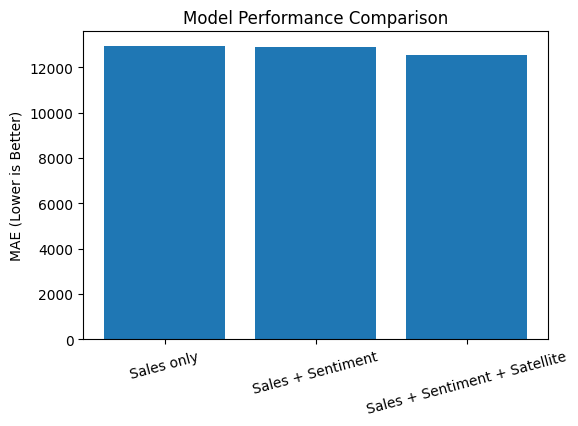

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['MAE'])
plt.ylabel('MAE (Lower is Better)')
plt.title('Model Performance Comparison')
plt.xticks(rotation=15)
plt.show()


STEP 8: LSTM-BASED MULTIMODAL MODEL (CAMT-INSPIRED)

In [ ]:
features = ['sales', 'sentiment', 'avg_brightness']
data = merged[features].values


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [ ]:
def create_sequences(data, window=8):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window, 0])  # sales column
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window=8)

X.shape, y.shape


((112, 8, 3), (112,))

In [ ]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mae'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - loss: 0.4432 - val_loss: 0.3060
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2112 - val_loss: 0.1046
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1764 - val_loss: 0.2167
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1835 - val_loss: 0.1251
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1527 - val_loss: 0.1006
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1569 - val_loss: 0.1168
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1556 - val_loss: 0.1028
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1479 - val_loss: 0.0948
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1482 - val_loss: 0.0943
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1487 - val_loss: 0.0966
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1461 - val_loss: 0.0976
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1464 - val_loss: 0.0995


In [ ]:
pred_lstm = model.predict(X_test).flatten()

# invert scaling for sales only
sales_min = scaler.data_min_[0]
sales_max = scaler.data_max_[0]

pred_lstm_real = pred_lstm * (sales_max - sales_min) + sales_min
y_test_real = y_test * (sales_max - sales_min) + sales_min

from sklearn.metrics import mean_absolute_error
mae_lstm = mean_absolute_error(y_test_real, pred_lstm_real)
mae_lstm


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


12577.276327576326

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Linear (Sales only)',
        'Linear (Sales + Sentiment)',
        'Linear (Sales + Sentiment + Satellite)',
        'LSTM Multimodal'
    ],
    'MAE': [
        mae_base,
        mae_sent,
        mae_full,
        mae_lstm
    ]
})

comparison


,Model,MAE
0,Linear (Sales only),12934.340660
1,Linear (Sales + Sentiment),12910.047725
2,Linear (Sales + Sentiment + Satellite),12555.871360
3,LSTM Multimodal,12577.276328


In [ ]:
merged['sales'].mean()
merged['sales'].min()
merged['sales'].max()


211390

Calculate Percentage MAE

In [ ]:
# Average sales
avg_sales = merged['sales'].mean()

# Percentage MAE for full multimodal model
percentage_error = (mae_full / avg_sales) * 100

print("Average Weekly Sales:", avg_sales)
print("MAE (Full Model):", mae_full)
print("Percentage Error (%):", percentage_error)


Average Weekly Sales: 175408.65833333333
MAE (Full Model): 12555.871360366451
Percentage Error (%): 7.15806818184894


In [ ]:
models = {
    "Sales Only": mae_base,
    "Sales + Sentiment": mae_sent,
    "Sales + Sentiment + Satellite": mae_full
}

for name, mae in models.items():
    perc = (mae / avg_sales) * 100
    print(f"{name} → MAE: {mae:.2f} | Relative Error: {perc:.2f}%")


Sales Only → MAE: 12934.34 | Relative Error: 7.37%
Sales + Sentiment → MAE: 12910.05 | Relative Error: 7.36%
Sales + Sentiment + Satellite → MAE: 12555.87 | Relative Error: 7.16%


##GRU

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense


In [ ]:
gru_model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mae'
)

gru_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#STEP 3: Train GRU
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.3390 - val_loss: 0.1625
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1689 - val_loss: 0.1478
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1918 - val_loss: 0.1410
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1663 - val_loss: 0.0943
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1551 - val_loss: 0.1198
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1558 - val_loss: 0.1084
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1479 - val_loss: 0.0934
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1469 - val_loss: 0.0982
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1488 - val_loss: 0.0958
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1469 - val_loss: 0.0972
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1478 - val_loss: 0.0994
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1455 - val_loss: 0.0958
E

In [ ]:
# STEP 4: Evaluate GRU
pred_gru = gru_model.predict(X_test).flatten()

# Inverse scaling for sales
sales_min = scaler.data_min_[0]
sales_max = scaler.data_max_[0]

pred_gru_real = pred_gru * (sales_max - sales_min) + sales_min
y_test_real = y_test * (sales_max - sales_min) + sales_min

from sklearn.metrics import mean_absolute_error
mae_gru = mean_absolute_error(y_test_real, pred_gru_real)

mae_gru


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


11958.58128481326

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Linear (Full)',
        'LSTM',
        'GRU'
    ],
    'MAE': [
        mae_full,
        mae_lstm,
        mae_gru
    ]
})

comparison


,Model,MAE
0,Linear (Full),12555.871360
1,LSTM,12577.276328
2,GRU,11958.581285


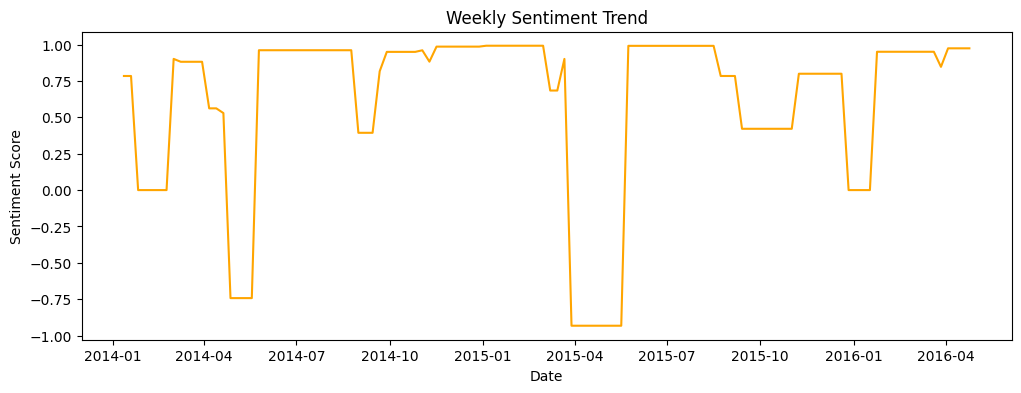

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(merged['date'], merged['sentiment'], color='orange')
plt.title("Weekly Sentiment Trend")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.show()


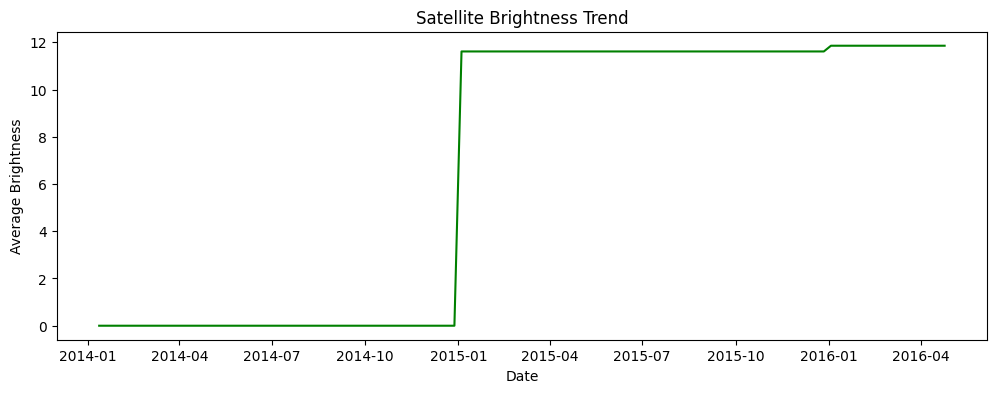

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(merged['date'], merged['avg_brightness'], color='green')
plt.title("Satellite Brightness Trend")
plt.xlabel("Date")
plt.ylabel("Average Brightness")
plt.show()


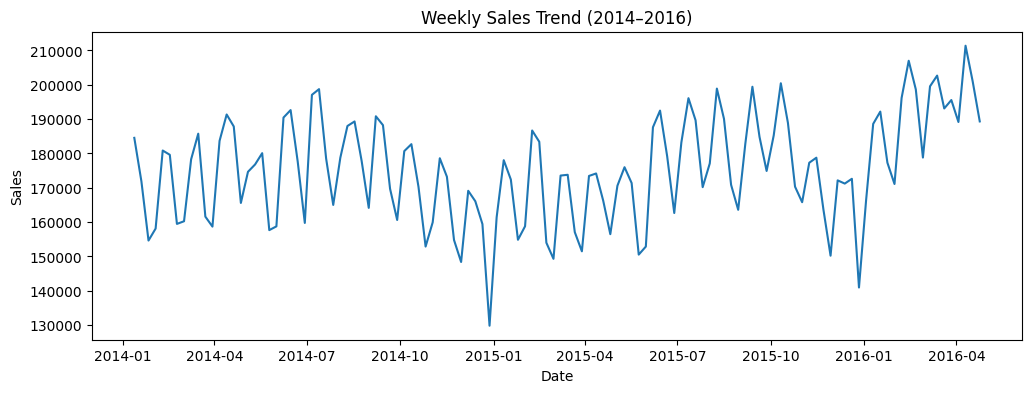

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(merged['date'], merged['sales'])
plt.title("Weekly Sales Trend (2014–2016)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


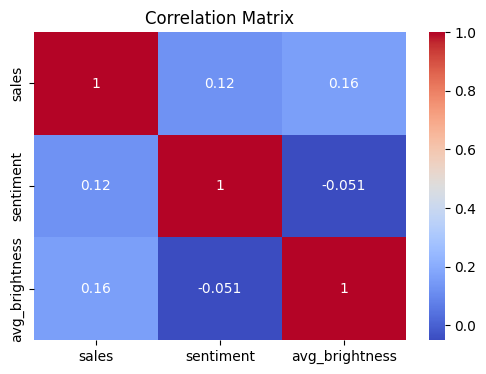

In [ ]:
import seaborn as sns

corr = merged[['sales', 'sentiment', 'avg_brightness']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


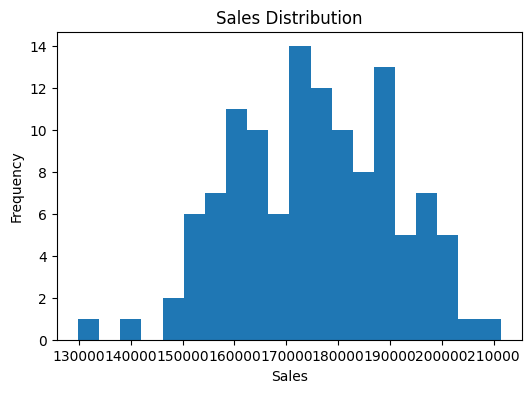

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(merged['sales'], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


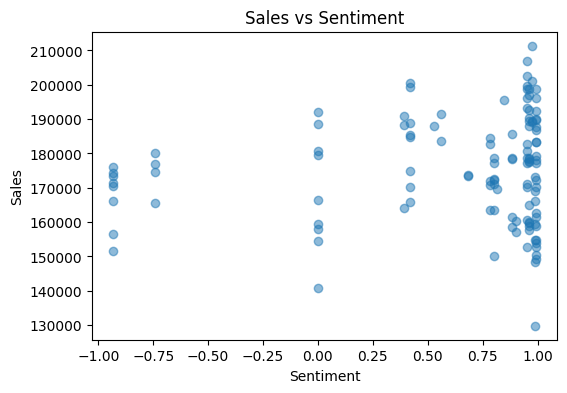

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(merged['sentiment'], merged['sales'], alpha=0.5)
plt.title("Sales vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Sales")
plt.show()


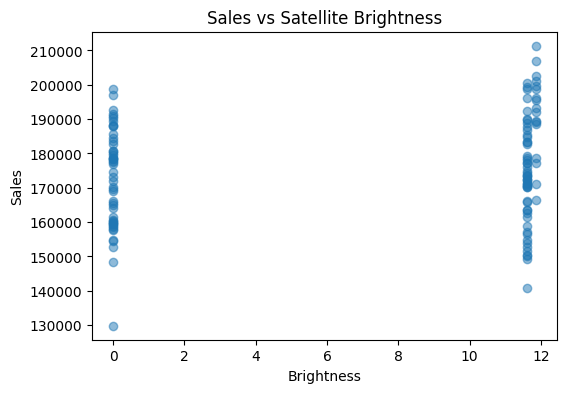

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(merged['avg_brightness'], merged['sales'], alpha=0.5)
plt.title("Sales vs Satellite Brightness")
plt.xlabel("Brightness")
plt.ylabel("Sales")
plt.show()


In [ ]:
import numpy as np
from scipy import stats

# Central tendency
print("Sales Mean:", merged['sales'].mean())
print("Sales Median:", merged['sales'].median())
print("Sales Mode:", stats.mode(merged['sales'], keepdims=True)[0][0])

print("\nSentiment Mean:", merged['sentiment'].mean())
print("Sentiment Median:", merged['sentiment'].median())

print("\nBrightness Mean:", merged['avg_brightness'].mean())
print("Brightness Median:", merged['avg_brightness'].median())


Sales Mean: 175408.65833333333
Sales Median: 176394.5
Sales Mode: 129811

Sentiment Mean: 0.6242745833333334
Sentiment Median: 0.9503

Brightness Mean: 6.7134032072337755
Brightness Median: 11.615689526463562


In [ ]:
correlation = merged['avg_brightness'].corr(merged['sales'])
print(f"Correlation between avg_brightness and sales: {correlation:.4f}")

Correlation between avg_brightness and sales: 0.1616


In [ ]:
print("Sales Standard Deviation:", merged['sales'].std())
print("Sales Variance:", merged['sales'].var())
print("Sales Range:", merged['sales'].max() - merged['sales'].min())

print("\nSentiment Standard Deviation:", merged['sentiment'].std())
print("Brightness Standard Deviation:", merged['avg_brightness'].std())


Sales Standard Deviation: 15448.564198327493
Sales Variance: 238658135.78984597
Sales Range: 81579

Sentiment Standard Deviation: 0.5753068183512354
Brightness Standard Deviation: 5.79644079021482


In [ ]:
from scipy.stats import skew, kurtosis

print("Sales Skewness:", skew(merged['sales']))
print("Sales Kurtosis:", kurtosis(merged['sales']))

print("\nSentiment Skewness:", skew(merged['sentiment']))
print("Sentiment Kurtosis:", kurtosis(merged['sentiment']))


Sales Skewness: -0.12955391916609066
Sales Kurtosis: -0.37054908987705737

Sentiment Skewness: -1.7649951265148278
Sentiment Kurtosis: 1.898851284989604


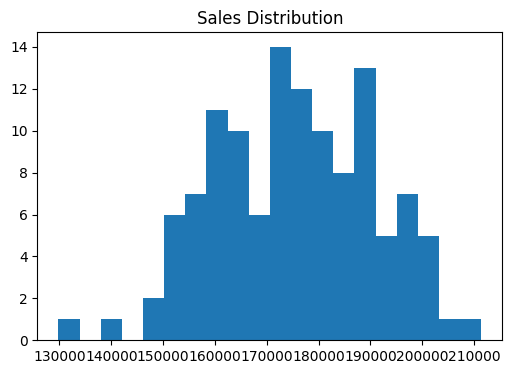

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(merged['sales'], bins=20)
plt.title("Sales Distribution")
plt.show()


polynomial regression model

In [ ]:
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_absolute_error

In [ ]:
# X_train = train[['sales_lag1']]
# y_train = train['sales']

# X_test  = test[['sales_lag1']]
# y_test  = test['sales']

In [ ]:
# #Step 3: Apply Polynomial Transformation

# #👉 Degree = 2 (safe and sufficient)

# poly = PolynomialFeatures(degree=2)

# X_train_poly = poly.fit_transform(X_train)
# X_test_poly  = poly.transform(X_test)

In [ ]:
# model_poly = LinearRegression()
# model_poly.fit(X_train_poly, y_train)

In [ ]:
# pred_poly = model_poly.predict(X_test_poly)

In [ ]:
# mae_poly = mean_absolute_error(y_test, pred_poly)
# mae_poly

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 🔹 Use all features
X_train = train[['sales_lag1', 'sentiment', 'avg_brightness']]
y_train = train['sales']

X_test  = test[['sales_lag1', 'sentiment', 'avg_brightness']]
y_test  = test['sales']


# 🔹 Polynomial Transformation (Degree 2)
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)


# 🔹 Train Model
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)


# 🔹 Prediction
pred_poly = model_poly.predict(X_test_poly)


# 🔹 Evaluation
mae_poly = mean_absolute_error(y_test, pred_poly)
print("Polynomial MAE (Multimodal):", mae_poly)

Polynomial MAE (Multimodal): 11414.687121815388


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Linear',
        'Polynomial (Degree 2)',
        'LSTM',
        'GRU'
    ],
    'MAE': [
        mae_base,
        mae_poly,
        mae_lstm,
        mae_gru
    ]
})

comparison

,Model,MAE
0,Linear,12934.340660
1,Polynomial (Degree 2),11414.687122
2,LSTM,12577.276328
3,GRU,11958.581285


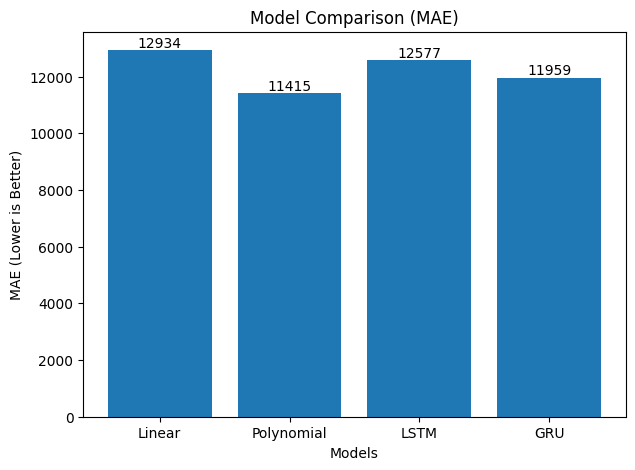

In [ ]:
import matplotlib.pyplot as plt

models = [
    'Linear',
    'Polynomial',
    'LSTM',
    'GRU'
]

mae_values = [
    mae_base,
    mae_poly,
    mae_lstm,
    mae_gru
]

plt.figure(figsize=(7,5))
plt.bar(models, mae_values)

plt.title("Model Comparison (MAE)")
plt.xlabel("Models")
plt.ylabel("MAE (Lower is Better)")

for i, v in enumerate(mae_values):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.show()

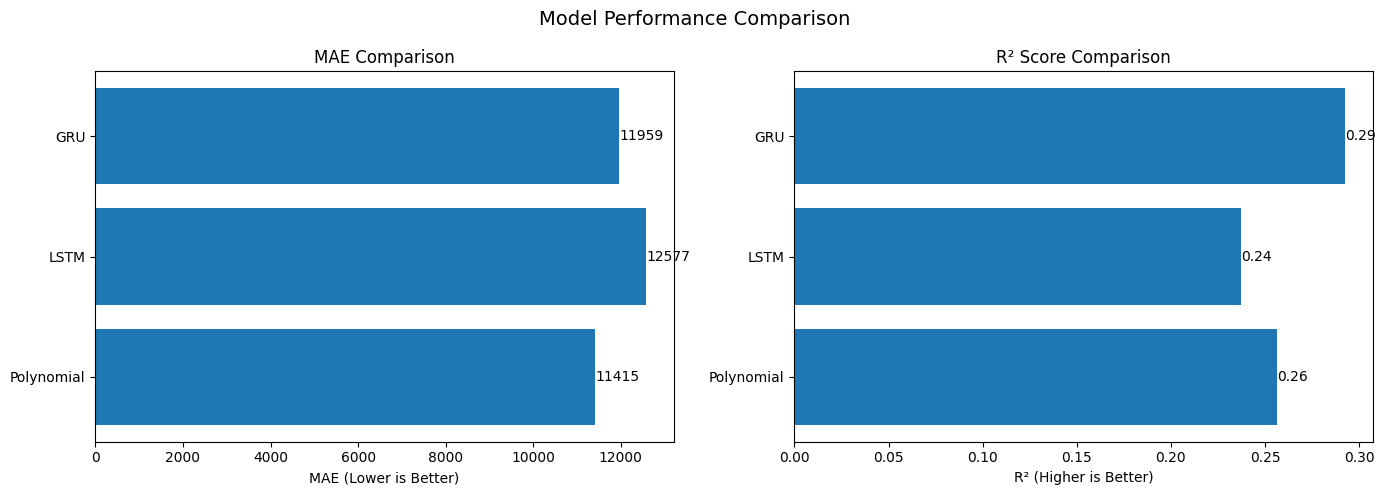

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Predictions already available:
# pred_poly, pred_lstm_real, pred_gru_real

# Calculate R2 scores
r2_poly = r2_score(y_test, pred_poly)
r2_lstm = r2_score(y_test_real, pred_lstm_real)
r2_gru  = r2_score(y_test_real, pred_gru_real)

# Model names
models = ['Polynomial', 'LSTM', 'GRU']

# Metrics
mae_values = [mae_poly, mae_lstm, mae_gru]
r2_values  = [r2_poly, r2_lstm, r2_gru]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 MAE Plot
axes[0].barh(models, mae_values)
axes[0].set_title("MAE Comparison")
axes[0].set_xlabel("MAE (Lower is Better)")

for i, v in enumerate(mae_values):
    axes[0].text(v, i, f"{v:.0f}", va='center')

# 🔹 R2 Plot
axes[1].barh(models, r2_values)
axes[1].set_title("R² Score Comparison")
axes[1].set_xlabel("R² (Higher is Better)")

for i, v in enumerate(r2_values):
    axes[1].text(v, i, f"{v:.2f}", va='center')

# Main Title
plt.suptitle("Model Performance Comparison", fontsize=14)

plt.tight_layout()
plt.show()

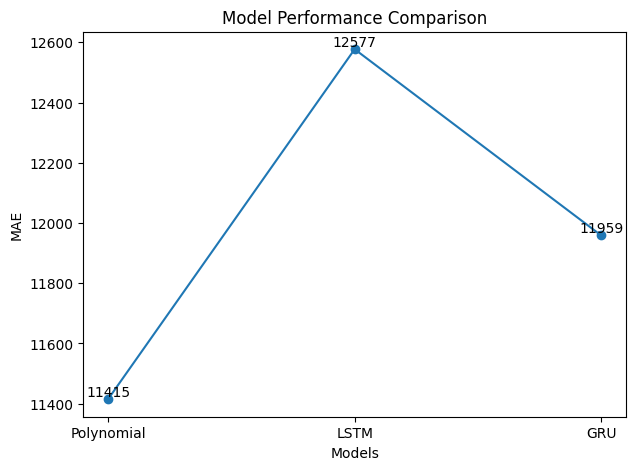

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(models, mae_values, marker='o')

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("MAE")

for i, v in enumerate(mae_values):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.show()

r2 for linear and lstm

In [ ]:
from sklearn.metrics import r2_score

# Linear / Polynomial (use whichever you used as baseline)
r2_linear = r2_score(y_test, pred_base)   # or pred_poly if using polynomial

# LSTM (use real-scaled values)
r2_lstm = r2_score(y_test_real, pred_lstm_real)

print("Linear R2:", r2_linear)
print("LSTM R2:", r2_lstm)

Linear R2: 0.16844309456193396
LSTM R2: 0.23704637350511326


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Performance:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

# Linear / Polynomial
evaluate_model(y_test, pred_poly, "Polynomial")

# LSTM
evaluate_model(y_test_real, pred_lstm_real, "LSTM")

# GRU
evaluate_model(y_test_real, pred_gru_real, "GRU")


Polynomial Performance:
MAE: 11414.687121815388
RMSE: 15043.70159562814
R2 Score: 0.25646953498406355

LSTM Performance:
MAE: 12577.276327576326
RMSE: 15540.157019265287
R2 Score: 0.23704637350511326

GRU Performance:
MAE: 11958.58128481326
RMSE: 14963.732854775304
R2 Score: 0.2925964599989578


Text(0.5, 1.0, 'Actual vs Predicted Sales')

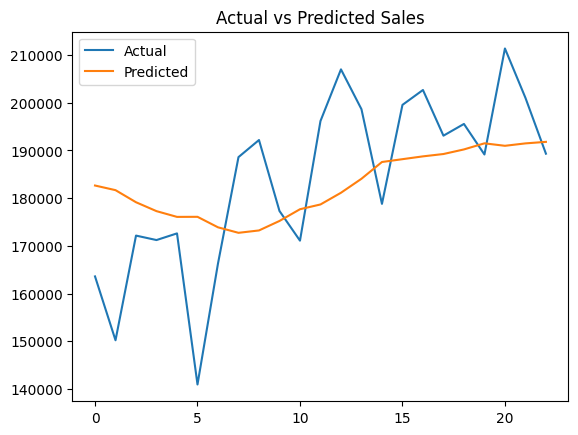

In [ ]:
plt.plot(y_test_real[:50], label='Actual')
plt.plot(pred_lstm_real[:50], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")

Ploynomial Model

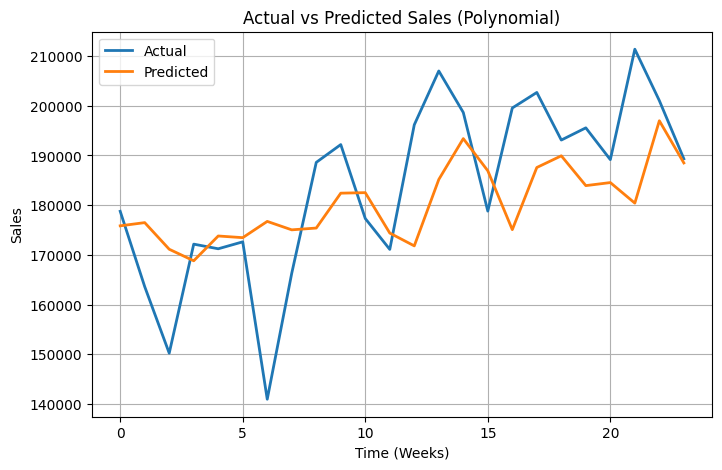

In [ ]:
plt.figure(figsize=(8,5))

# Reset index for alignment
actual = y_test.reset_index(drop=True)
pred   = pd.Series(pred_poly).reset_index(drop=True)

# Plot same range
plt.plot(actual[:50], label='Actual', linewidth=2)
plt.plot(pred[:50], label='Predicted', linewidth=2)

plt.title("Actual vs Predicted Sales (Polynomial)")
plt.xlabel("Time (Weeks)")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

GRU

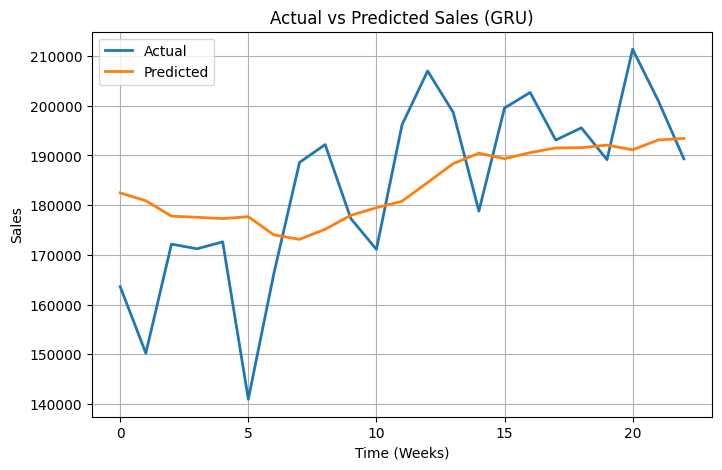

In [ ]:
plt.figure(figsize=(8,5))

actual = pd.Series(y_test_real).reset_index(drop=True)
pred   = pd.Series(pred_gru_real).reset_index(drop=True)

plt.plot(actual[:50], label='Actual', linewidth=2)
plt.plot(pred[:50], label='Predicted', linewidth=2)

plt.title("Actual vs Predicted Sales (GRU)")
plt.xlabel("Time (Weeks)")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()